## 📦 Section 1 — Library Imports
> All required Python libraries are imported below. We use **pandas** for data wrangling,
> **numpy** for numerical operations, **matplotlib** and **seaborn** for visualisation,
> and **scikit-learn** to load the Iris benchmark dataset.

In [12]:
import pandas as pd                     
import numpy as np                     
import matplotlib.pyplot as plt         
import matplotlib.patches as mpatches   
import seaborn as sns                  


print("✅  All libraries loaded successfully.")


✅  All libraries loaded successfully.


## 📂 Section 2 — Data Acquisition & Initial Inspection
> We load the **Fisher Iris dataset** (150 rows × 5 columns) directly from
> `sklearn.datasets`. Each row represents one flower; the four numeric columns
> measure sepal/petal length and width in centimetres.

In [2]:
from sklearn.datasets import load_iris

raw    = load_iris()
df     = pd.DataFrame(data=raw.data, columns=raw.feature_names)
df["species"] = pd.Categorical.from_codes(raw.target, raw.target_names)

# Prettier column names (remove unit suffix for display convenience)
RENAME = {
    "sepal length (cm)": "Sepal Length",
    "sepal width (cm)" : "Sepal Width",
    "petal length (cm)": "Petal Length",
    "petal width (cm)" : "Petal Width",
    "species"          : "Species",
}
df.rename(columns=RENAME, inplace=True)
FEATURES = ["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"]

print(f"Dataset shape : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Species       : {list(df['Species'].unique())}")
print()
df.head(8)


Dataset shape : 150 rows × 5 columns
Species       : ['setosa', 'versicolor', 'virginica']



,Sepal Length,Sepal Width,Petal Length,Petal Width,Species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa


In [3]:

print("── Dataset Info─")
df.info()
print()
print("── Summary Statistics ─")
df.describe().round(2)


── Dataset Info─
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   Sepal Length  150 non-null    float64 
 1   Sepal Width   150 non-null    float64 
 2   Petal Length  150 non-null    float64 
 3   Petal Width   150 non-null    float64 
 4   Species       150 non-null    category
dtypes: category(1), float64(4)
memory usage: 5.1 KB

── Summary Statistics ─


,Sepal Length,Sepal Width,Petal Length,Petal Width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


---
## 📊 Section 3 — Average Feature Values per Species
> A grouped bar chart showing the **mean** of every measurement broken down by species.
> This gives an immediate visual sense of which species is larger or smaller overall.

C:\Users\Hetvi\AppData\Local\Temp\ipykernel_5096\3789483214.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  means = df.groupby("Species")[FEATURES].mean()


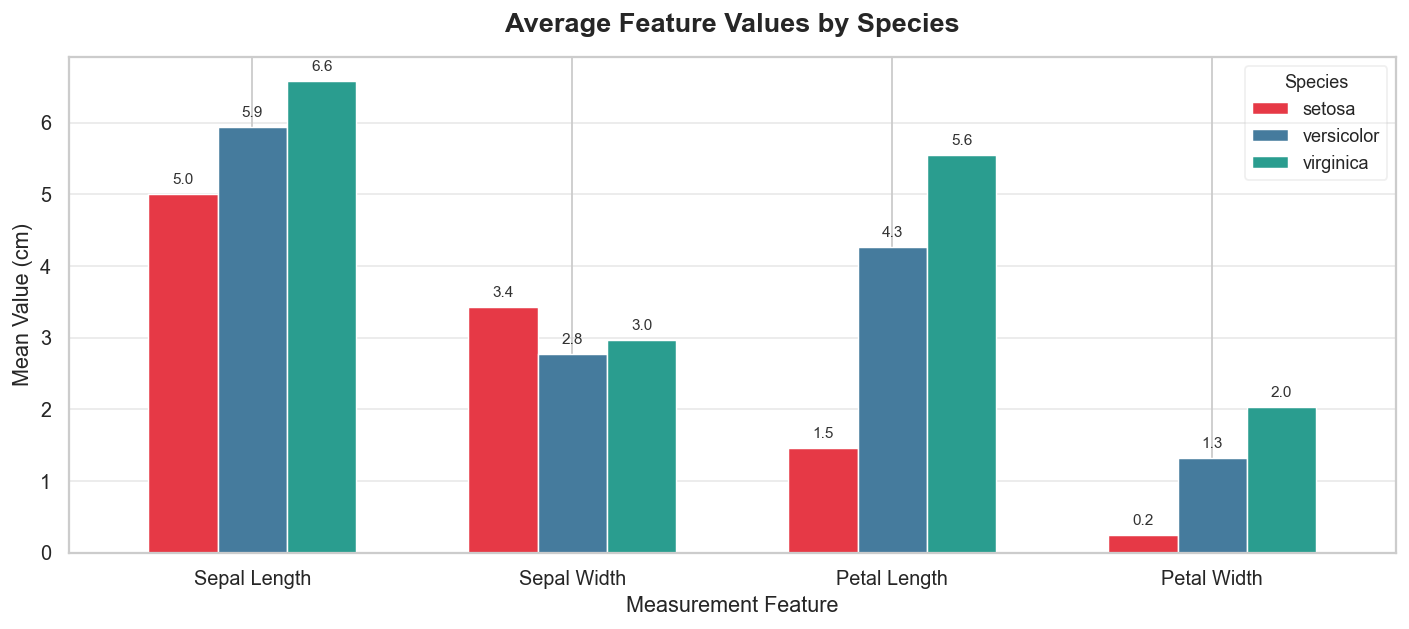

Figure saved → plot_01_avg_features.png


In [4]:

SPECIES_PALETTE = {"setosa": "#e63946", "versicolor": "#457b9d", "virginica": "#2a9d8f"}

means = df.groupby("Species")[FEATURES].mean()

fig, ax = plt.subplots(figsize=(11, 5))
means.T.plot(
    kind="bar",
    ax=ax,
    color=[SPECIES_PALETTE[s] for s in means.index],
    edgecolor="white",
    linewidth=0.8,
    width=0.65,
)
ax.set_title("Average Feature Values by Species", fontsize=15, fontweight="bold", pad=14)
ax.set_xlabel("Measurement Feature", fontsize=12)
ax.set_ylabel("Mean Value (cm)", fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
ax.legend(title="Species", title_fontsize=10, fontsize=10, framealpha=0.3)
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)

# Value annotations on every bar
for bar in ax.patches:
    h = bar.get_height()
    ax.annotate(f"{h:.1f}",
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points",
                ha="center", va="bottom", fontsize=8.5, color="#333")

plt.tight_layout()
plt.savefig("plot_01_avg_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → plot_01_avg_features.png")


In [5]:

means.round(1).style \
    .background_gradient(cmap="YlOrRd", axis=None) \
    .set_caption("Mean Feature Values (cm) by Species") \
    .format("{:.1f}")


,Sepal Length,Sepal Width,Petal Length,Petal Width
Species,,,,
setosa,5.0,3.4,1.5,0.2
versicolor,5.9,2.8,4.3,1.3
virginica,6.6,3.0,5.6,2.0


### 💡 Key Observations — Average Features

| Feature | Smallest | Largest |
|---------|----------|---------|
| **Sepal Length** | Setosa (~5.0 cm) | Virginica (~6.6 cm) |
| **Sepal Width** | Versicolor (~2.8 cm) | Setosa (~3.4 cm) |
| **Petal Length** | Setosa (~1.5 cm) | Virginica (~5.6 cm) |
| **Petal Width** | Setosa (~0.3 cm) | Virginica (~2.0 cm) |

> **Takeaway :** Petal length and petal width show the greatest *relative* spread across species,
> hinting that they will be the strongest discriminators in a classifier.

---
## 📈 Section 4 — Feature Distributions (Histograms)
> Individual frequency histograms reveal the *shape* of each measurement's distribution —
> whether it is symmetric, skewed, or bimodal — before any species grouping is applied.

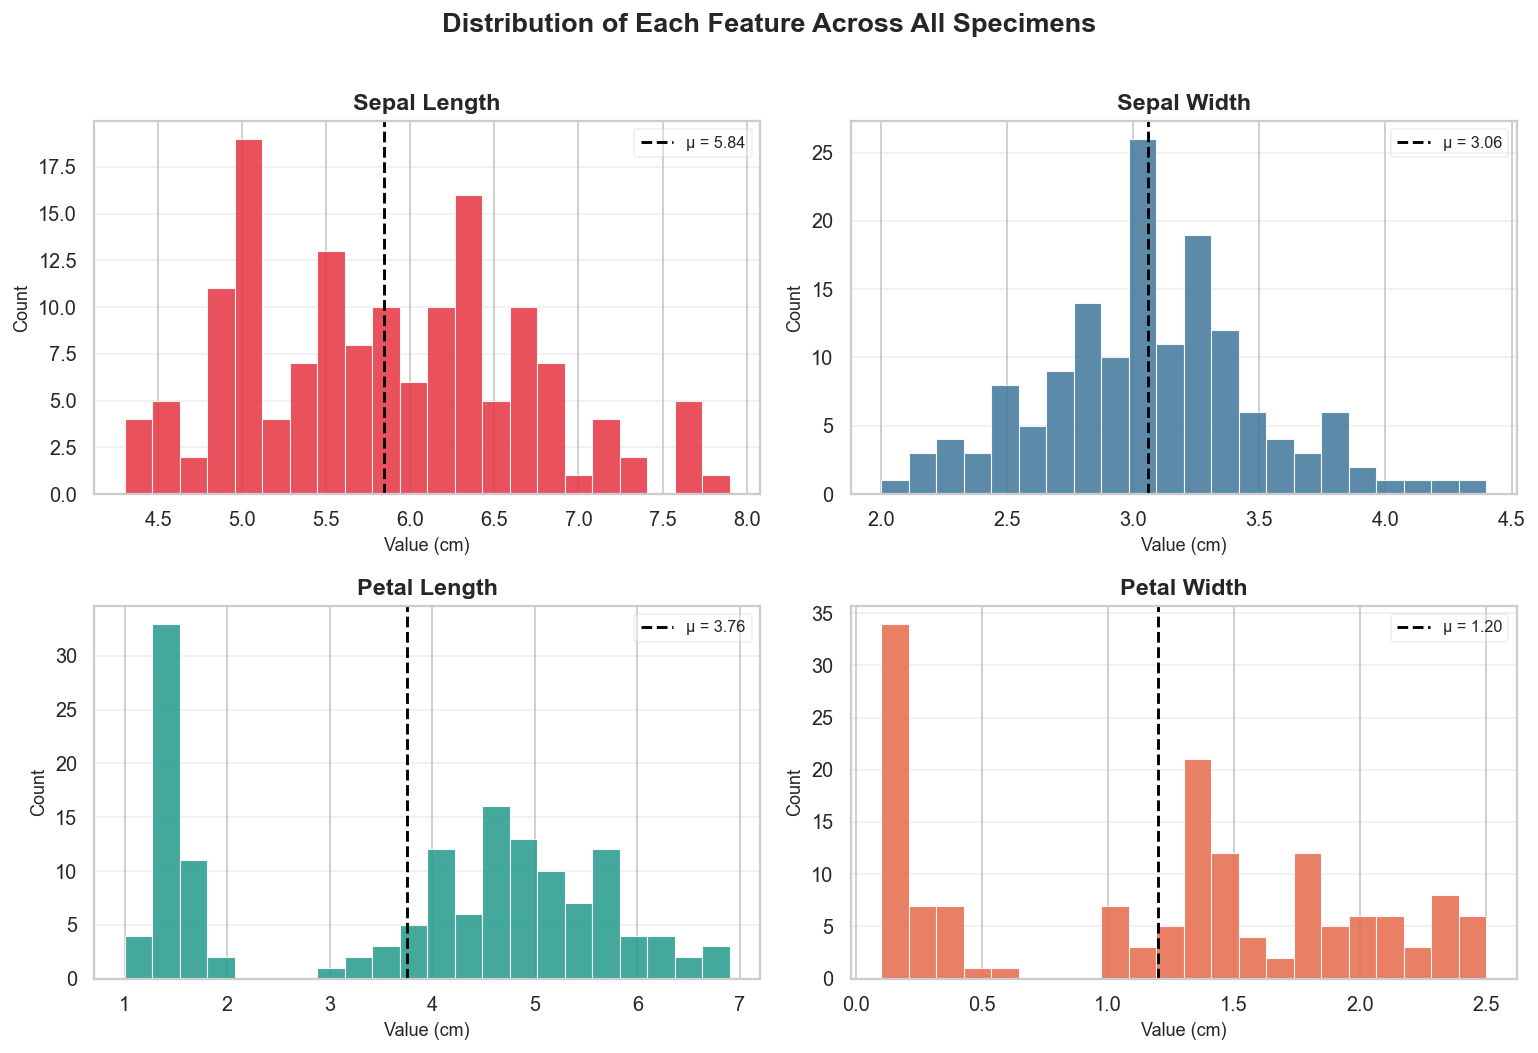

Figure saved → plot_02_histograms.png


In [6]:

HIST_COLORS = ["#e63946", "#457b9d", "#2a9d8f", "#e76f51"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Distribution of Each Feature Across All Specimens",
             fontsize=15, fontweight="bold", y=1.01)

for ax, feat, color in zip(axes.flatten(), FEATURES, HIST_COLORS):
    ax.hist(df[feat], bins=22, color=color, edgecolor="white",
            linewidth=0.6, alpha=0.88)
    ax.axvline(df[feat].mean(), color="black", linewidth=1.6,
               linestyle="--", label=f"μ = {df[feat].mean():.2f}")
    ax.set_title(feat, fontsize=13, fontweight="semibold")
    ax.set_xlabel("Value (cm)", fontsize=10)
    ax.set_ylabel("Count", fontsize=10)
    ax.legend(fontsize=9, framealpha=0.3)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig("plot_02_histograms.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → plot_02_histograms.png")


### 💡 Key Observations — Distributions

- **Sepal Length** (4.5–8.0 cm) — mild bimodal shape; two species clusters are visible but overlapping.
- **Sepal Width** (2.0–4.5 cm) — closest to a **normal / unimodal** distribution; centred near 3.0 cm.
- **Petal Length** (1.0–7.0 cm) — **strong bimodal** with a sharp Setosa peak at ~1.5 cm and a gap at 2–3 cm.
- **Petal Width** (0.0–2.5 cm) — mirrors petal length; the near-zero cluster belongs exclusively to Setosa.

> **Takeaway :** The clear gap in petal length and petal width distributions naturally isolates Setosa, 
> making it trivially separable with a single threshold rule.

---
## 📦 Section 5 — Feature Spread by Species (Box Plots)
> Box plots show **median, IQR, and outlier** positions for each feature, broken down
> by species side-by-side. They make it easy to see both within-species variability and 
> between-species separation.

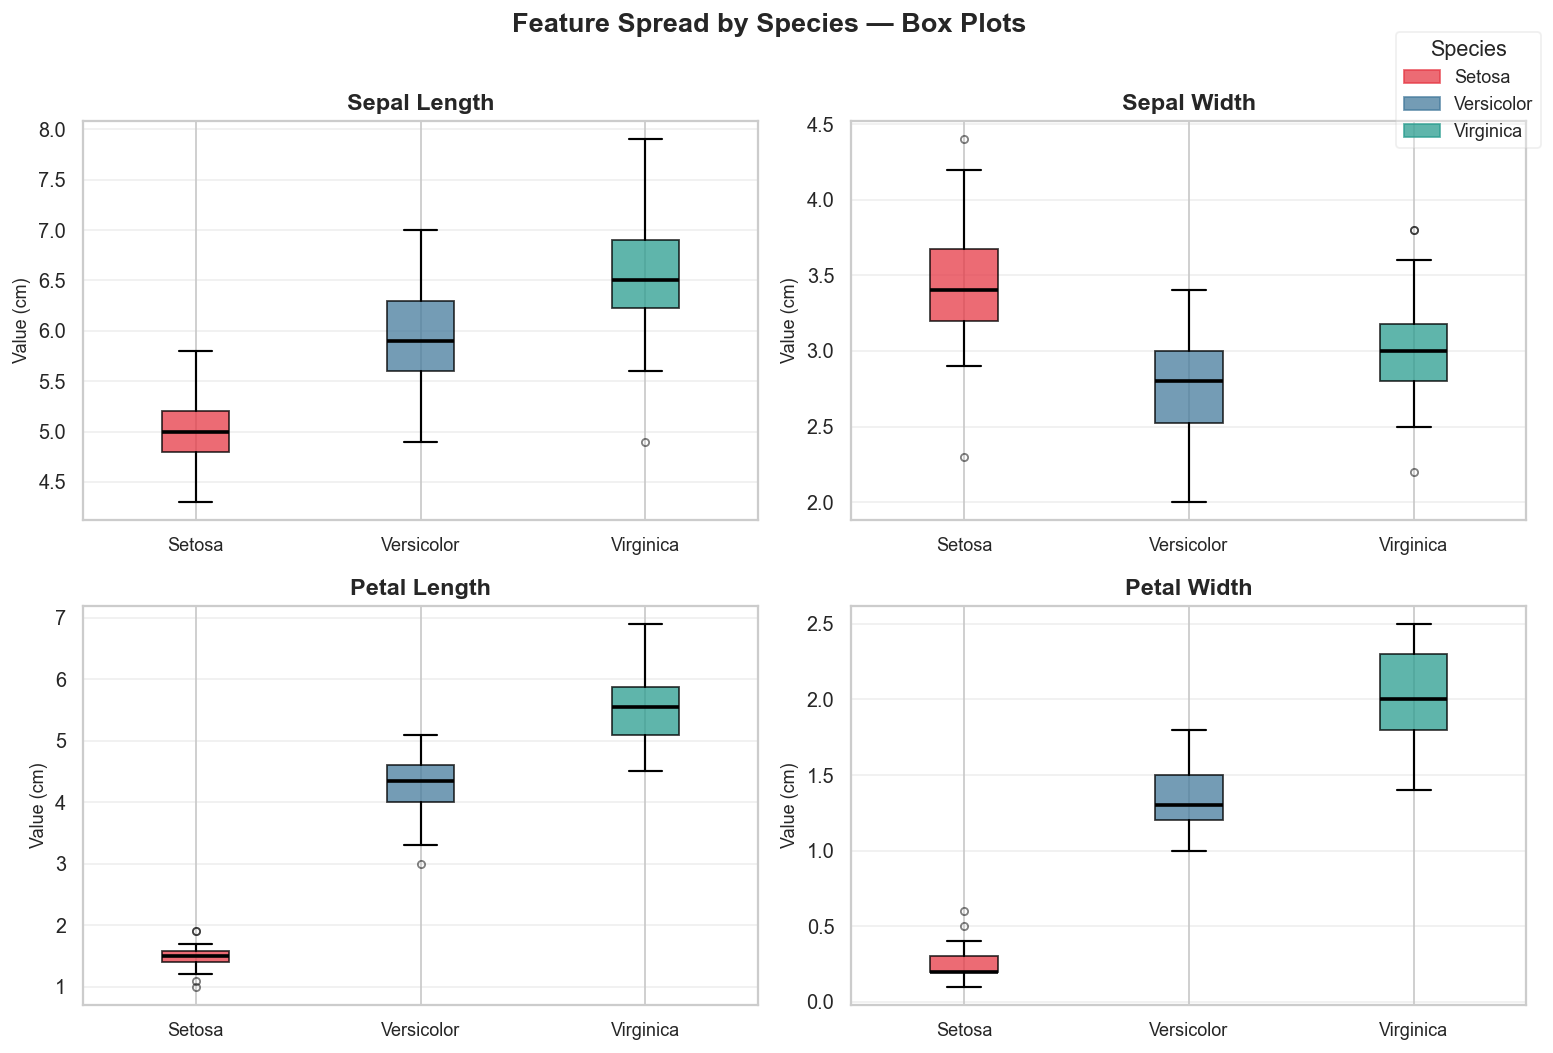

Figure saved → plot_03_boxplots.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Feature Spread by Species — Box Plots",
             fontsize=15, fontweight="bold", y=1.01)

for ax, feat in zip(axes.flatten(), FEATURES):
    groups = [df.loc[df["Species"] == sp, feat].values
              for sp in ["setosa", "versicolor", "virginica"]]
    bp = ax.boxplot(groups, patch_artist=True,
                    medianprops=dict(color="black", linewidth=2),
                    whiskerprops=dict(linewidth=1.2),
                    capprops=dict(linewidth=1.2),
                    flierprops=dict(marker="o", markersize=4, alpha=0.5))
    for patch, color in zip(bp["boxes"], SPECIES_PALETTE.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_xticklabels(["Setosa", "Versicolor", "Virginica"], fontsize=10)
    ax.set_title(feat, fontsize=13, fontweight="semibold")
    ax.set_ylabel("Value (cm)", fontsize=10)
    ax.yaxis.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

# Manual legend
handles = [mpatches.Patch(color=c, label=s.capitalize(), alpha=0.75)
           for s, c in SPECIES_PALETTE.items()]
fig.legend(handles=handles, loc="upper right", bbox_to_anchor=(1.0, 1.0),
           fontsize=10, framealpha=0.3, title="Species")

plt.tight_layout()
plt.savefig("plot_03_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → plot_03_boxplots.png")


### 💡 Key Observations — Box Plots

- **Data quality** is excellent: outliers are sparse and isolated across all species and features.
- **Setosa** shows the most compact boxes (narrow IQR), especially for petal dimensions.
- **Virginica** has the widest spread in petal length and petal width.
- **Versicolor** sits between Setosa and Virginica across all four measurements.
- Petal boxes for Setosa show **zero overlap** with the other two species.

> **Takeaway :** The dataset is clean and reliable. Setosa is linearly separable from
> Versicolor/Virginica on petal dimensions alone.

---
## 🔗 Section 6 — Feature Correlation Heatmap
> Pearson correlations between all four numeric features are visualised as an annotated
> heatmap. Understanding inter-feature redundancy is critical before building any model.

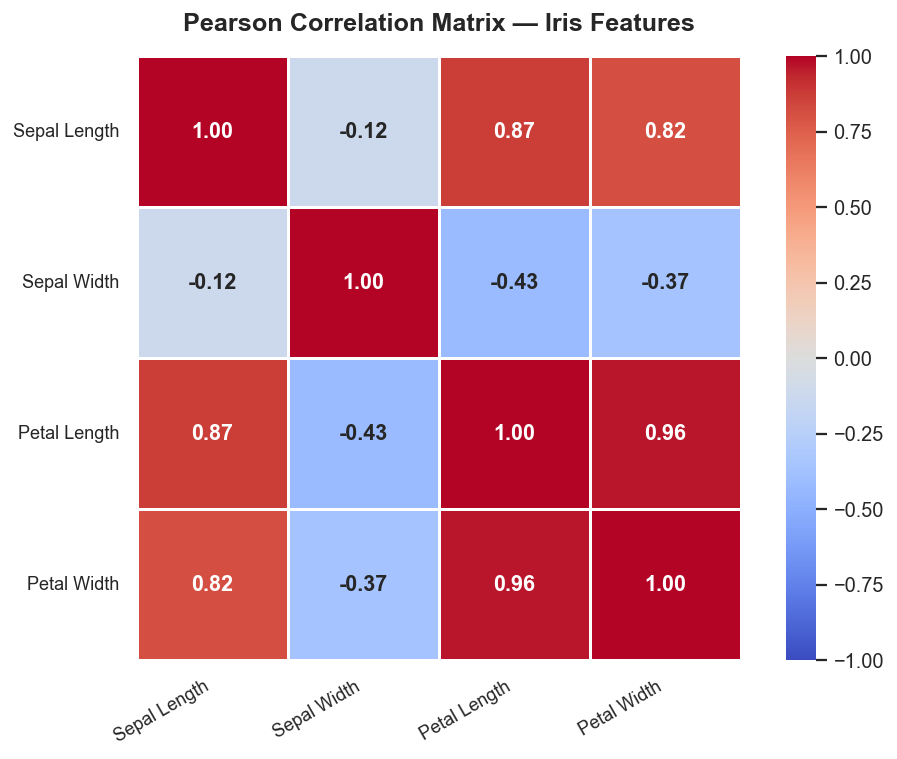

Figure saved → plot_04_heatmap.png


In [8]:

corr = df[FEATURES].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # upper-triangle mask

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.6,
    linecolor="white",
    square=True,
    ax=ax,
    annot_kws={"size": 12, "weight": "bold"},
)
ax.set_title("Pearson Correlation Matrix — Iris Features",
             fontsize=14, fontweight="bold", pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("plot_04_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → plot_04_heatmap.png")


### 💡 Key Observations — Correlations

| Pair | r | Interpretation |
|------|---|----------------|
| Petal Length ↔ Petal Width | **0.96** | Near-perfect positive — both grow proportionally |
| Sepal Length ↔ Petal Length | **0.87** | Strong positive — larger flowers have longer petals |
| Sepal Length ↔ Petal Width | **0.82** | Strong positive |
| Sepal Width ↔ Petal Length | **−0.43** | Moderate negative — wider sepals, shorter petals |
| Sepal Width ↔ Sepal Length | **−0.12** | Near-zero — almost independent |

> **Takeaway :** Petal Length and Petal Width are highly redundant (r = 0.96). 
> Sepal Width is the most **independent** feature — useful for ensemble models but a 
> weak classifier on its own.

---
## 🔵 Section 7 — Sepal Length vs Petal Length (Scatter)
> A two-dimensional scatter plot coloured by species reveals how well each species
> clusters in sepal × petal length space.

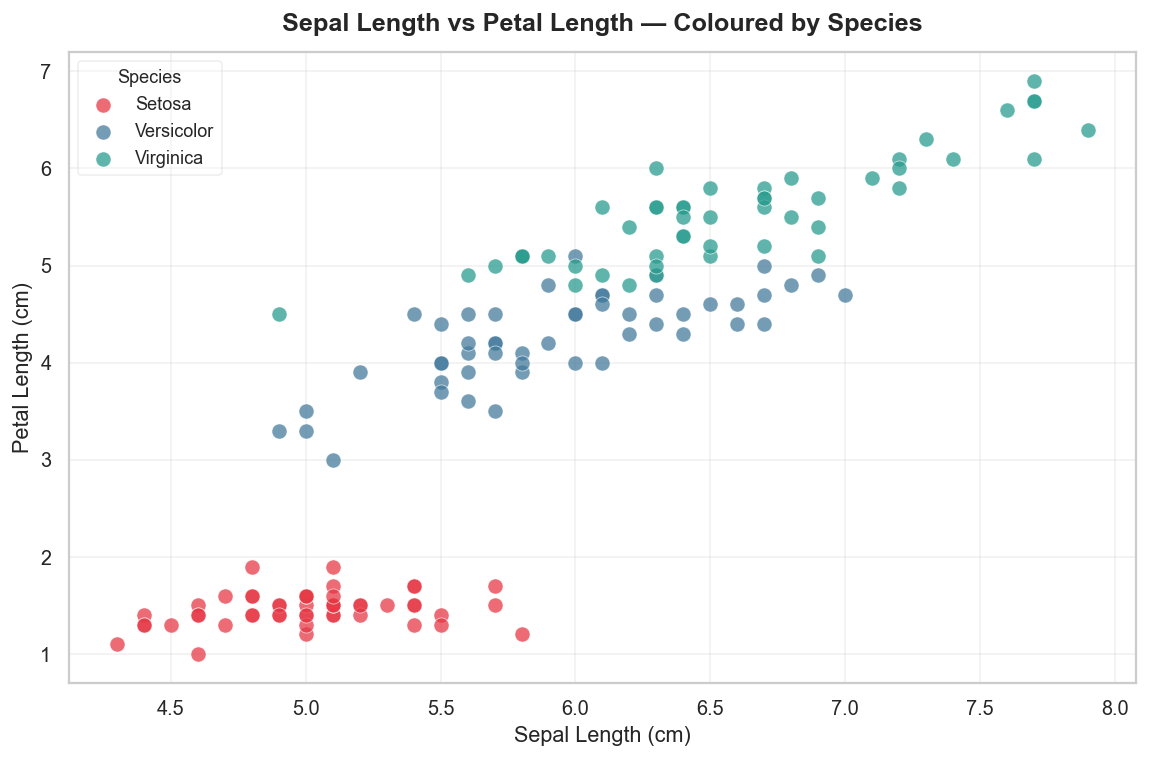

Figure saved → plot_05_scatter_sepal_petal.png


In [9]:

fig, ax = plt.subplots(figsize=(9, 6))

for sp, color in SPECIES_PALETTE.items():
    subset = df[df["Species"] == sp]
    ax.scatter(subset["Sepal Length"], subset["Petal Length"],
               label=sp.capitalize(), color=color, alpha=0.75,
               edgecolors="white", linewidths=0.4, s=70)

ax.set_title("Sepal Length vs Petal Length — Coloured by Species",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Sepal Length (cm)", fontsize=12)
ax.set_ylabel("Petal Length (cm)", fontsize=12)
ax.legend(title="Species", title_fontsize=10, fontsize=10, framealpha=0.3)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("plot_05_scatter_sepal_petal.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → plot_05_scatter_sepal_petal.png")


---
## 🔍 Section 8 — Overlap Zone: Versicolor vs Virginica
> We quantify the region where Versicolor and Virginica specimens share the same
> sepal-length × petal-length space, making classification difficult.

In [10]:

SL_MIN, SL_MAX = 5.5, 7.0
PL_MIN, PL_MAX = 3.0, 5.5

def in_overlap(sub):
    return sub[
        sub["Sepal Length"].between(SL_MIN, SL_MAX) &
        sub["Petal Length"].between(PL_MIN, PL_MAX)
    ]

versi    = df[df["Species"] == "versicolor"]
virgi    = df[df["Species"] == "virginica"]
ov_versi = in_overlap(versi)
ov_virgi = in_overlap(virgi)

print("─── Overlap Zone Report ─────────────────────────────────────────")
print(f"  Zone definition  : Sepal Length [{SL_MIN}–{SL_MAX} cm]  "
      f"AND  Petal Length [{PL_MIN}–{PL_MAX} cm]")
print(f"  Versicolor inside: {len(ov_versi):>3} / {len(versi)}  "
      f"({100*len(ov_versi)/len(versi):.0f}%)")
print(f"  Virginica inside : {len(ov_virgi):>3} / {len(virgi)}  "
      f"({100*len(ov_virgi)/len(virgi):.0f}%)")
print("─────────────────────────────────────────────────────────────────")


─── Overlap Zone Report ─────────────────────────────────────────
  Zone definition  : Sepal Length [5.5–7.0 cm]  AND  Petal Length [3.0–5.5 cm]
  Versicolor inside:  44 / 50  (88%)
  Virginica inside :  24 / 50  (48%)
─────────────────────────────────────────────────────────────────


In [11]:

from matplotlib.patches import Rectangle, FancyArrowPatch

fig, ax = plt.subplots(figsize=(9, 6))

for sp, color in SPECIES_PALETTE.items():
    sub = df[df["Species"] == sp]
    ax.scatter(sub["Sepal Length"], sub["Petal Length"],
               label=sp.capitalize(), color=color,
               alpha=0.65, edgecolors="white", linewidths=0.4, s=70)

# Overlap rectangle
rect = Rectangle((SL_MIN, PL_MIN), SL_MAX - SL_MIN, PL_MAX - PL_MIN,
                 linewidth=2, edgecolor="#ff9f1c", facecolor="#ff9f1c",
                 alpha=0.15, linestyle="--", zorder=2)
ax.add_patch(rect)
ax.text(6.25, 4.1, "Overlap
Zone", ha="center", va="center",
        fontsize=10, color="#c77b00", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.6))

ax.set_title("Sepal Length vs Petal Length — Overlap Zone Highlighted",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Sepal Length (cm)", fontsize=12)
ax.set_ylabel("Petal Length (cm)", fontsize=12)
ax.legend(title="Species", fontsize=10, title_fontsize=10, framealpha=0.3)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("plot_06_overlap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → plot_06_overlap.png")


SyntaxError: unterminated string literal (detected at line 16) (4283694303.py, line 16)

### 💡 Key Observations — Overlap Zone

| Species | In Overlap Zone | Total | Percentage |
|---------|----------------|-------|------------|
| **Setosa** | 0 | 50 | 0% |
| **Versicolor** | 44 | 50 | **88%** |
| **Virginica** | 24 | 50 | 48% |

- **Setosa** is perfectly isolated in the bottom-left and never enters the overlap zone.
- **88% of Versicolor** specimens occupy the same sepal × petal space as Virginica, 
  making single-feature classification unreliable for this pair.
- **Virginica** is better defined: roughly half its population sits clearly above 5.5 cm petal length
  with no Versicolor neighbour.

> **Takeaway :** Sepal and petal length alone cannot separate Versicolor from Virginica.
> Multi-dimensional modelling (e.g., adding petal width) is necessary.

---
## 🟣 Section 9 — Sepal Width vs Petal Width (Scatter)
> We now examine the width dimensions to see whether they offer additional
> separability power beyond the length measurements.

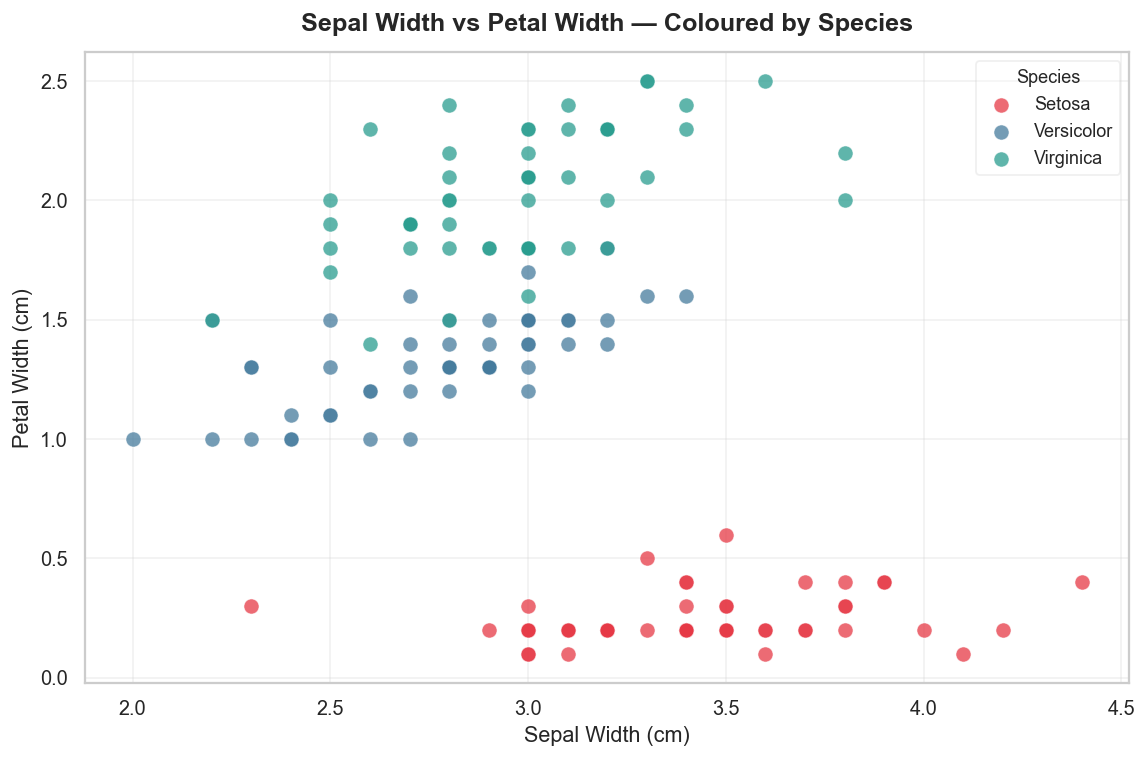

Figure saved → plot_07_scatter_widths.png


In [14]:

fig, ax = plt.subplots(figsize=(9, 6))

for sp, color in SPECIES_PALETTE.items():
    sub = df[df["Species"] == sp]
    ax.scatter(sub["Sepal Width"], sub["Petal Width"],
               label=sp.capitalize(), color=color,
               alpha=0.75, edgecolors="white", linewidths=0.4, s=70)

ax.set_title("Sepal Width vs Petal Width — Coloured by Species",
             fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Sepal Width (cm)", fontsize=12)
ax.set_ylabel("Petal Width (cm)", fontsize=12)
ax.legend(title="Species", fontsize=10, title_fontsize=10, framealpha=0.3)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig("plot_07_scatter_widths.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved → plot_07_scatter_widths.png")


---
## 🔢 Section 10 — All-Feature Pair Plot
> A pair plot shows every possible two-feature combination simultaneously.
> Diagonal cells show per-species KDE distributions; off-diagonal cells are scatter plots.

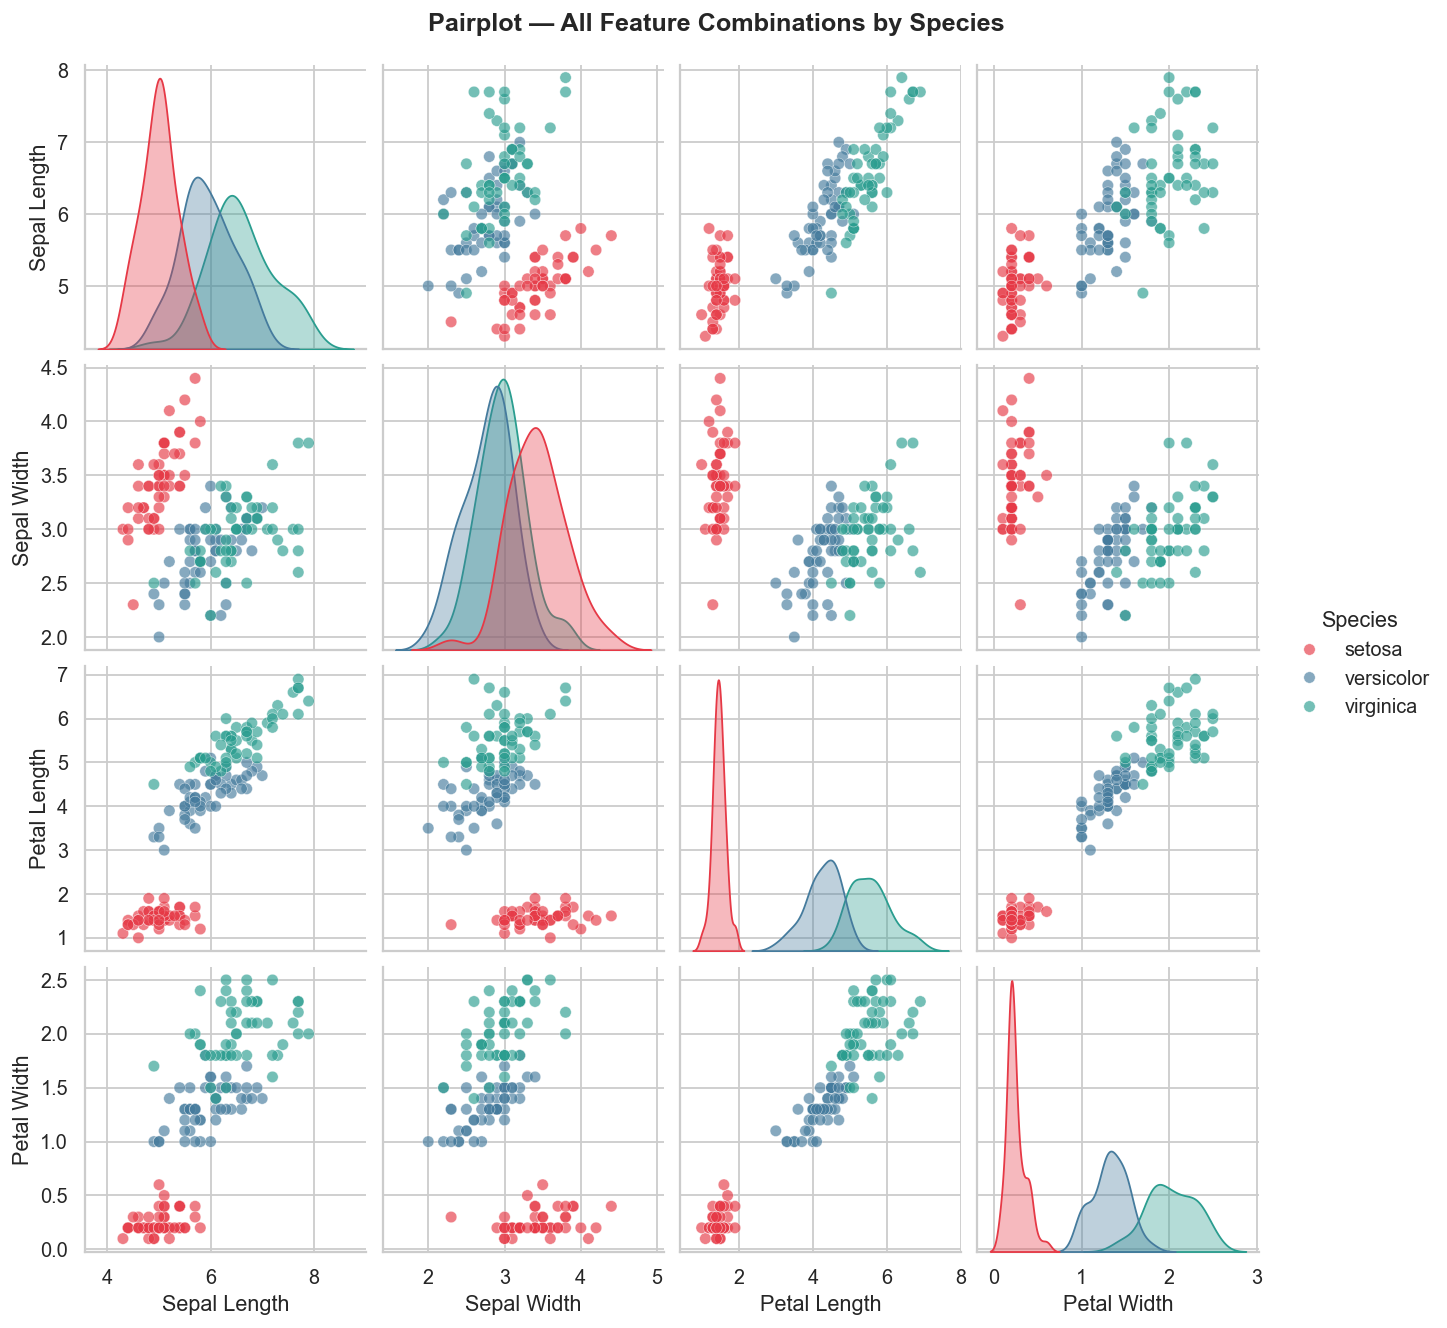

Figure saved → plot_08_pairplot.png


In [13]:

pp = sns.pairplot(
    df,
    hue="Species",
    palette=SPECIES_PALETTE,
    diag_kind="kde",
    plot_kws={"alpha": 0.65, "edgecolor": "white", "linewidth": 0.3, "s": 40},
    diag_kws={"fill": True, "alpha": 0.35},
    corner=False,
)
pp.figure.suptitle("Pairplot — All Feature Combinations by Species",
                   y=1.02, fontsize=14, fontweight="bold")

pp.figure.savefig("plot_08_pairplot.png", dpi=130, bbox_inches="tight")
plt.show()
print("Figure saved → plot_08_pairplot.png")


### 💡 Key Observations — Pair Plot

- **Petal Length × Petal Width** panel offers the clearest three-way separation.
- **Setosa** appears as a tight, isolated cluster in every single panel — confirming 100% linear separability.
- **Sepal Width** panels are the most *scattered*, confirming it is the weakest single discriminator.
- KDE diagonal curves for Setosa are narrow and sharp; Versicolor and Virginica overlap in several features.

> **Takeaway :** No single 2-D feature pair perfectly separates all three species.
> Petal dimensions are optimal; combining all four features unlocks the best classification accuracy.